<a href="https://colab.research.google.com/github/ge25anshika-hue/Loan_Prediction_Model/blob/main/Loan_Approval_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix,accuracy_score,roc_curve,classification_report
import seaborn as sns
from sklearn import svm
%matplotlib inline
import matplotlib.pyplot as plt


import warnings
warnings.filterwarnings('ignore')

In [ ]:
Finance = pd.read_csv("/content/Finance_data.csv")

In [ ]:
Finance

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [ ]:
Finance.shape

(614, 13)

In [ ]:
Finance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [ ]:
Finance.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [ ]:
Finance.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


**Missing values Imputation**

<Axes: xlabel='Gender', ylabel='count'>

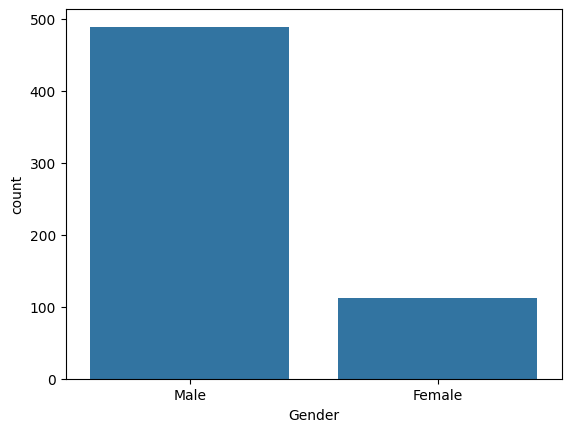

In [ ]:
sns.countplot(x = Finance['Gender'])

In [ ]:
Finance['Gender'].mode()[0]

'Male'

In [ ]:
Finance['Gender'] = Finance['Gender'].fillna('Male')

<Axes: xlabel='Married', ylabel='count'>

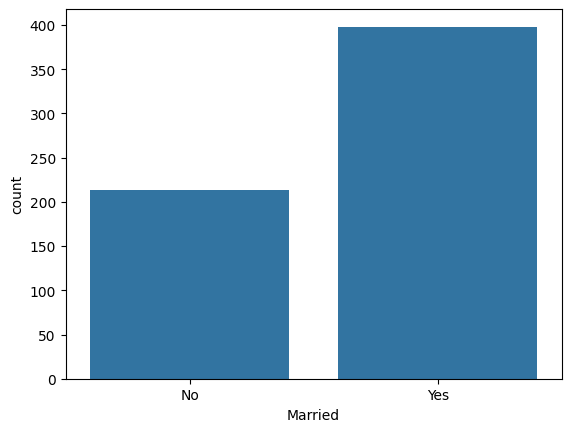

In [ ]:
sns.countplot(x= Finance['Married'])

In [ ]:
Finance['Married'] = Finance['Married'].fillna('Yes')

<Axes: xlabel='Dependents', ylabel='count'>

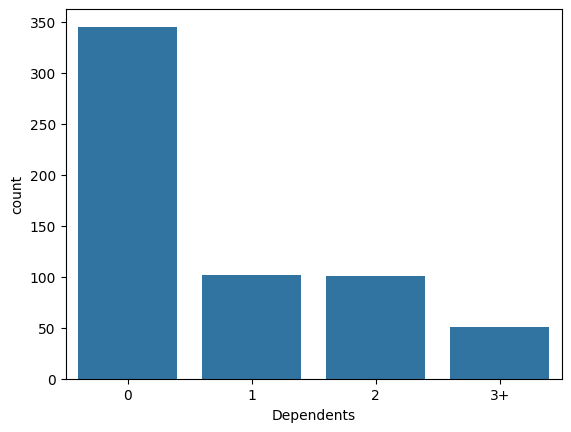

In [ ]:
sns.countplot(x=Finance['Dependents'])

In [ ]:
Finance['Dependents']= Finance['Dependents'].fillna('0')

<Axes: xlabel='Self_Employed', ylabel='count'>

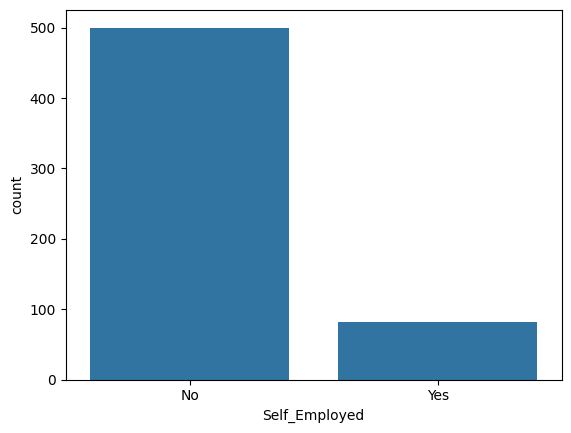

In [ ]:
sns.countplot(x = Finance['Self_Employed'])

In [ ]:
Finance['Self_Employed'] = Finance['Self_Employed'].fillna('No')

In [ ]:
Finance['LoanAmount'] = Finance['LoanAmount'].fillna(Finance['LoanAmount'].median())

In [ ]:
Finance['Loan_Amount_Term'] = Finance['Loan_Amount_Term'].fillna(Finance['Loan_Amount_Term'].median())

<Axes: xlabel='Credit_History', ylabel='count'>

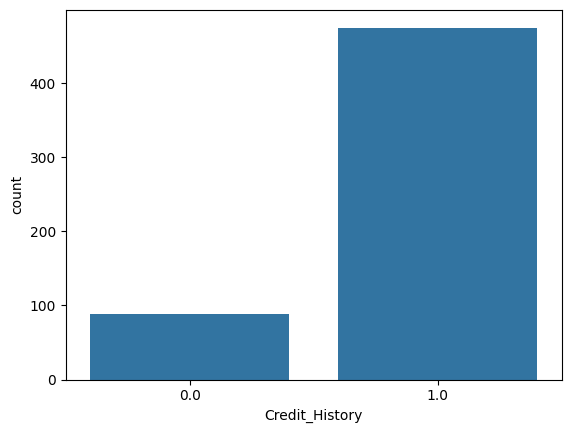

In [ ]:
sns.countplot(x = Finance['Credit_History'])

In [ ]:
Finance['Credit_History'] = Finance['Credit_History'].fillna('1.0')

In [ ]:
Finance.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [ ]:
Finance.replace({
    "Loan_Status": {'N': 0, 'Y': 1},
    "Gender": {'Male': 0, 'Female': 1},
    "Education": {'Not Graduate': 0, 'Graduate': 1},
    "Married": {'No': 0, 'Yes': 1},
    "Self_Employed": {'No': 0, 'Yes': 1}
}, inplace=True)

In [ ]:
Finance.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,0,0,0,1,0,5849,0.0,128.0,360.0,1.0,Urban,1
1,LP001003,0,1,1,1,0,4583,1508.0,128.0,360.0,1.0,Rural,0
2,LP001005,0,1,0,1,1,3000,0.0,66.0,360.0,1.0,Urban,1
3,LP001006,0,1,0,0,0,2583,2358.0,120.0,360.0,1.0,Urban,1
4,LP001008,0,0,0,1,0,6000,0.0,141.0,360.0,1.0,Urban,1


<Axes: xlabel='Education', ylabel='count'>

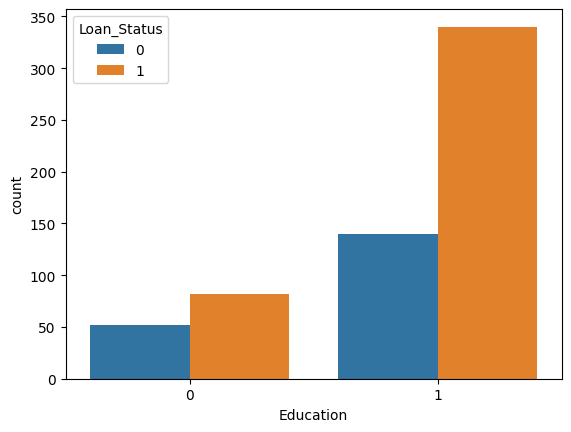

In [ ]:
sns.countplot(x = 'Education', hue='Loan_Status', data=Finance)

**Train Test Split**

In [ ]:
def train_test_split_and_features(Finance):
    y = Finance["Loan_Status"]
    x = Finance.drop(['Loan_Status', 'Loan_ID'], axis=1)
    x = pd.get_dummies(data = x, columns = ["Property_Area","Dependents"])
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, stratify = y, random_state = 42)
    print(x.head(5))
    print(x.columns)
    features = list(x.columns)
    return x_train, x_test, y_train, y_test,features

In [ ]:

x_train, x_test, y_train, y_test,features = train_test_split_and_features(Finance)

   Gender  Married  Education  Self_Employed  ApplicantIncome  \
0       0        0          1              0             5849   
1       0        1          1              0             4583   
2       0        1          1              1             3000   
3       0        1          0              0             2583   
4       0        0          1              0             6000   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term Credit_History  \
0                0.0       128.0             360.0            1.0   
1             1508.0       128.0             360.0            1.0   
2                0.0        66.0             360.0            1.0   
3             2358.0       120.0             360.0            1.0   
4                0.0       141.0             360.0            1.0   

   Property_Area_Rural  Property_Area_Semiurban  Property_Area_Urban  \
0                False                    False                 True   
1                 True                    False   

**RANDOM FOREST CLASSIFIER**

In [ ]:
def fit_and_evaluate_model(x_train, x_test, y_train, y_test):
    random_forest =  RandomForestClassifier(random_state=0,\
                                            max_depth=5,\
                                            min_samples_split= 0.01,\
                                            max_features= 0.8,
                                            max_samples= 0.8)

    model = random_forest.fit(x_train, y_train)
    random_forest_predict = random_forest.predict(x_test)
    random_forest_conf_matrix = confusion_matrix(y_test, random_forest_predict)
    random_forest_acc_score = accuracy_score(y_test, random_forest_predict)
    print("confussion matrix")
    print(random_forest_conf_matrix)
    print("\n")
    print("Accuracy of Random Forest:",random_forest_acc_score*100,'\n')
    print(classification_report(y_test,random_forest_predict))
    return model

In [ ]:
model = fit_and_evaluate_model(x_train, x_test, y_train, y_test)

confussion matrix
[[20 18]
 [ 2 83]]


Accuracy of Random Forest: 83.73983739837398 

              precision    recall  f1-score   support

           0       0.91      0.53      0.67        38
           1       0.82      0.98      0.89        85

    accuracy                           0.84       123
   macro avg       0.87      0.75      0.78       123
weighted avg       0.85      0.84      0.82       123



**LOGISTIC REGRESSION**

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
model = LogisticRegression()

In [ ]:
# Features and Target
X = Finance.drop(columns='Loan_Status', axis=1)
Y = Finance['Loan_Status']

# Convert Dependents first (because of '3+')
X['Dependents'] = X['Dependents'].replace('3+', 3)

# Convert all categorical columns automatically
X = pd.get_dummies(X, drop_first=True)

# Train-Test Split
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)

model.fit(x_train, y_train)

# Prediction
y_pred = model.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7886178861788617


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# Predictions
rf_pred = model.predict(x_test)

# Probability of approval
rf_proba = model.predict_proba(x_test)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nAccuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_proba))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Confusion Matrix:
[[18 25]
 [ 1 79]]

Accuracy: 0.7886178861788617
Precision: 0.7596153846153846
Recall: 0.9875
F1 Score: 0.8586956521739131
ROC-AUC: 0.7511627906976744

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



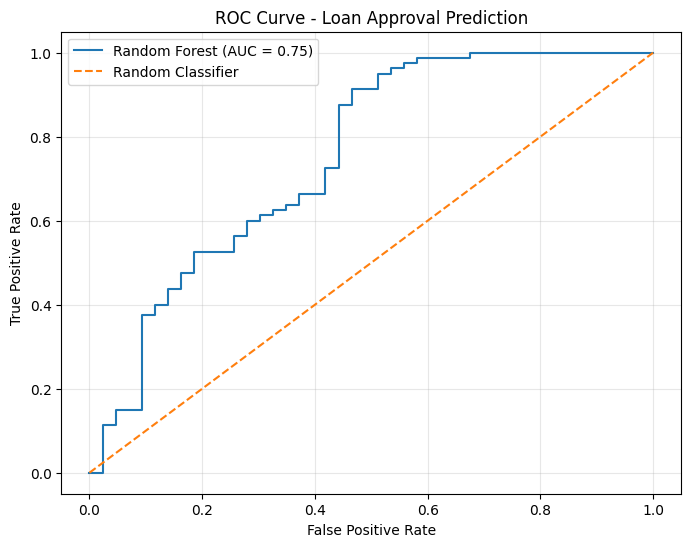

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(
    y_test,
    rf_proba
)

# Calculate AUC
auc_score = roc_auc_score(
    y_test,
    rf_proba
)

# Plot ROC curve
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {auc_score:.2f})"
)

# Random classifier line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Loan Approval Prediction")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
def calculate_woe_iv(data, feature, target):

    temp = data[[feature, target]].copy()

    # Numerical variable
    if pd.api.types.is_numeric_dtype(temp[feature]):

        temp["bin"] = pd.qcut(
            temp[feature],
            q=10,
            duplicates="drop"
        )

    # Categorical variable
    else:
        temp["bin"] = temp[feature].fillna("Missing").astype(str)

    grouped = temp.groupby("bin", observed=False)[target].agg(
        ["count", "sum"]
    )

    grouped["bad"] = grouped["sum"]
    grouped["good"] = grouped["count"] - grouped["bad"]

    # Prevent division by zero
    grouped["good"] = grouped["good"].replace(0, 0.5)
    grouped["bad"] = grouped["bad"].replace(0, 0.5)

    grouped["dist_good"] = (
        grouped["good"] / grouped["good"].sum()
    )

    grouped["dist_bad"] = (
        grouped["bad"] / grouped["bad"].sum()
    )

    grouped["WOE"] = np.log(
        grouped["dist_good"] / grouped["dist_bad"]
    )

    grouped["IV"] = (
        grouped["dist_good"] - grouped["dist_bad"]
    ) * grouped["WOE"]

    iv = grouped["IV"].sum()

    return grouped, iv

In [ ]:
TARGET = "Loan_Status"

iv_results = []
woe_tables = {}

features = [
    col for col in Finance.columns
    if col not in [TARGET, "Loan_ID"]
]

for feature in features:

    try:
        woe_table, iv = calculate_woe_iv(
            Finance,
            feature,
            TARGET
        )

        iv_results.append([feature, iv])
        woe_tables[feature] = woe_table

    except Exception as e:
        print("Skipped:", feature, e)

iv_df = pd.DataFrame(
    iv_results,
    columns=["Feature", "IV"]
).sort_values(
    "IV",
    ascending=False
)

iv_df


,Feature,IV
9,Credit_History,1.555207
10,Property_Area,0.096228
8,Loan_Amount_Term,0.041648
5,ApplicantIncome,0.030574
2,Dependents,0.024660
6,CoapplicantIncome,0.021696
7,LoanAmount,0.017211
1,Married,0.000000
0,Gender,0.000000
3,Education,0.000000


In [ ]:
def iv_strength(iv):

    if iv < 0.02:
        return "Useless"
    elif iv < 0.10:
        return "Weak"
    elif iv < 0.30:
        return "Medium"
    elif iv < 0.50:
        return "Strong"
    else:
        return "Suspicious"

iv_df["Strength"] = iv_df["IV"].apply(iv_strength)

iv_df

,Feature,IV,Strength
9,Credit_History,1.555207,Suspicious
10,Property_Area,0.096228,Weak
8,Loan_Amount_Term,0.041648,Weak
5,ApplicantIncome,0.030574,Weak
2,Dependents,0.024660,Weak
6,CoapplicantIncome,0.021696,Weak
7,LoanAmount,0.017211,Useless
1,Married,0.000000,Useless
0,Gender,0.000000,Useless
3,Education,0.000000,Useless


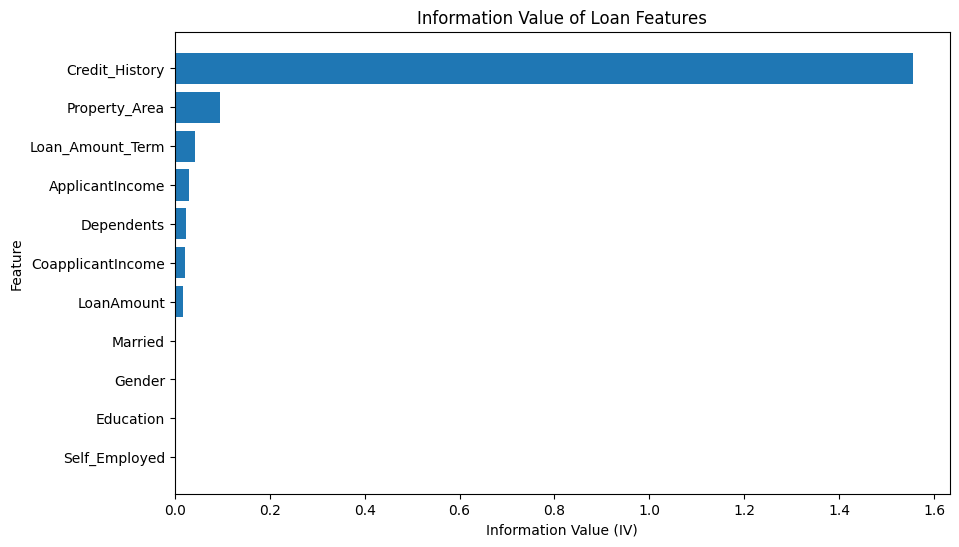

In [ ]:
plt.figure(figsize=(10, 6))

plt.barh(
    iv_df["Feature"],
    iv_df["IV"]
)

plt.xlabel("Information Value (IV)")
plt.ylabel("Feature")
plt.title("Information Value of Loan Features")

plt.gca().invert_yaxis()
plt.show()

In [ ]:
selected_features = iv_df[
    iv_df["IV"] >= 0.02
]["Feature"].tolist()

selected_features

['Credit_History',
 'Property_Area',
 'Loan_Amount_Term',
 'ApplicantIncome',
 'Dependents',
 'CoapplicantIncome']

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

In [ ]:
y_pred_log = log_model.predict(X_test_scaled)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.715447,0.695652,1.0000,0.820513,0.767151
1,Random Forest,0.788618,0.759615,0.9875,0.858696,0.751163
